# Level 2 — NumPy, Vectorization, Floating Point Errors, and Numerical Reliability

## Overview

In Level 1 we established the scientific foundation of HydroSense-Kenya by framing
the problem, understanding the datasets, and writing the two core functions that
drive the entire project. In this level we shift focus to **how** we compute —
not just what we compute.

Level 2 addresses a fundamental question in scientific computing:

> "Does it matter how we write our numerical code, as long as the answer is correct?"

The answer is yes — for two distinct reasons:

**Reason 1 — Performance.**
In real agricultural systems, we may need to compute evapotranspiration and water
balance across thousands of sensor readings, farm zones, and simulated days.
Loop-based Python code becomes unacceptably slow at that scale. NumPy vectorization
solves this by performing operations on entire arrays at once, using optimized
low-level routines under the hood.

**Reason 2 — Numerical Reliability.**
Computers do not represent decimal numbers exactly. This introduces small but
accumulating errors into every calculation. In a scientific system that chains
many calculations together — as our water balance model does — these errors
can propagate and compound, potentially leading to incorrect irrigation
recommendations. Understanding where these errors come from and how they
behave is not optional in scientific computing.

## What This Level Covers

1. Computing evapotranspiration using ordinary Python loops
2. Computing the same values using NumPy vectorization
3. Comparing execution time between both approaches
4. Demonstrating floating point behaviour and its implications
5. Running an error propagation experiment on irrigation recommendations
6. Discussing why numerical reliability matters in scientific computing

## Task 1 — Computing Evapotranspiration Using Python Loops

Before introducing NumPy, we first compute evapotranspiration the
straightforward way — using a standard Python for loop that iterates
over each day one at a time. This is the most intuitive approach and
closely mirrors how we might think about the calculation manually.

While correct, this approach has a significant limitation: it processes
one value at a time, which becomes increasingly slow as the dataset grows.
We will quantify exactly how slow in the timing comparison that follows.

**Evapotranspiration Formula: ET = max(0, 0.12·T + 0.35·W + 2.4·Solar − 0.025·H)**

In [7]:
#first we import the datasets and required modules , to get the data that we are going to use for this example.

import pandas as pd
import matplotlib.pyplot as plt

weather = pd.read_csv("../data/raw/weather_daily.csv",na_values=["NA",""])
soil = pd.read_csv("../data/raw/soil_sensor_data.csv",na_values=["NA",""])
params = pd.read_csv("../data/raw/crop_zone_parameters.csv",na_values=["NA",""])

print("\nWeather DataFrame : \n")
print(weather.info())
print("\nSoil DataFrame : \n")
print(soil.info())
print("\nParams DataFrame : \n")
print(params.info())





Weather DataFrame : 

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.5 KB
None

Soil DataFrame : 

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          90 non-null     str    
 1   zone_id            90 non-null     str    
 2   soil_moisture_pct  89 non-null     float64
 3   tank_level_liters  90 non-null     int64  
 4   pump_flow_lpm      90 non-null     float64
 5   pump_power_watts   90

In [11]:
import time
#Evapotranspiration Formula: ET = max(0, 0.12·T + 0.35·W + 2.4·Solar − 0.025·H)

#all the variables ( temperature, wind , solar & humidity) are in weather.

#calculating evapotranspiration using  ordinary python loops.

temperature = list(weather['temperature_c'].fillna(weather['temperature_c'].mean()))
wind = list(weather['wind_speed_mps'])
solar = list(weather['solar_index'])
humidity = list(weather['humidity_pct'].fillna(weather['humidity_pct'].mean()))

#function to calculate evapotranspiration.
def et_loop(temp,W,S,H):
    #create list to hold all the daily ET values
    et_values = []

    for i in range(len(temp)):
        et_value = max(0,(0.12*temp[i]+0.35*W[i]+2.4*S[i]-0.025*H[i]) )
        et_values.append(et_value)
    
    return et_values

#calculating the total time it takes to calculate ET using the loop.
start_time = time.time()
et_loop_results = et_loop(temperature,wind,solar,humidity)
stop_time = time.time()
execution_loop_time= stop_time - start_time

print("\n Results for ET using loops.\n")
print(et_loop_results)
print(f"Execution time taken by the loop : {execution_loop_time}")



 Results for ET using loops.

[3.7834999999999996, 3.8289999999999997, 4.144499999999999, 3.7485, 3.6310000000000002, 3.7844999999999995, 3.8264999999999993, 3.892999999999999, 3.7019999999999995, 3.5809999999999986, 3.73, 3.5334999999999996, 3.603999999999999, 5.9815000000000005, 3.1375, 3.6685000000000008, 3.5305, 4.0245, 4.310499999999999, 4.512499999999999, 3.910172413793104, 3.652, 3.5380000000000003, 2.817, 2.647499999999999, 2.906999999999999, 3.2750000000000004, 3.7664999999999997, 4.0365, 3.8179999999999996]
Execution time taken by the loop : 0.00013065338134765625


## Task 2 — Computing Evapotranspiration Using NumPy Vectorization

In Task 1 we computed ET by iterating over each day one at a time using a
Python for loop. In this task we compute the exact same values using
**NumPy vectorization** — a fundamentally different approach where the
entire operation is applied to all values simultaneously as a single
array operation.

Instead of telling Python "compute ET for day 1, then day 2, then day 3...",
vectorization says "compute ET for ALL days at once." This is possible because
NumPy stores arrays in contiguous memory blocks and delegates the computation
to pre-compiled C routines under the hood, bypassing the per-iteration
overhead that makes pure Python loops slow.

The result should be identical to Task 1 — the difference is not in the
answer but in how efficiently we arrive at it. We will measure and compare
the execution times of both approaches in Task 3.

In [15]:
import numpy as np
#creating the individual numpy arrays for temperature, wind, solar and humidity

temp_array = weather['temperature_c'].fillna(weather['temperature_c'].mean()).to_numpy()
wind_array = weather['wind_speed_mps'].to_numpy()
solar_array = weather['solar_index'].to_numpy()
humidity_array = weather['humidity_pct'].fillna(weather['humidity_pct'].mean()).to_numpy()

#function to calculate ET.

def et_vectorized(temp,wind,solar,humidity):
    """ 
    Function to calculate ET values using numpy arrays
    Parameters:
        temperature : numpy array 
        wind : numpy array
        solar : numpy array
        humidity : numpy array
    """
    #calculating ET for every day in the arrays.

    et = 0.12*temp + 0.35*wind + 2.4*solar - 0.025*humidity

    return np.maximum(0,et)

start_time = time.time()
et_vectorized_results = et_vectorized(temp_array,wind_array,solar_array,humidity_array)
stop_time = time.time()
execution_vectorized_time = stop_time - start_time

print("\n Results for vectorized ET calculations with numpy arrays.\n")
print(et_vectorized_results)
print(f"Execution time taken by vectorized operations : {execution_vectorized_time}")

#checking if the results from the loop operations is equal to the one for numpy arrays.

print("Results Match : ",np.allclose(et_loop_results,et_vectorized_results))


 Results for vectorized ET calculations with numpy arrays.

[3.7835     3.829      4.1445     3.7485     3.631      3.7845
 3.8265     3.893      3.702      3.581      3.73       3.5335
 3.604      5.9815     3.1375     3.6685     3.5305     4.0245
 4.3105     4.5125     3.91017241 3.652      3.538      2.817
 2.6475     2.907      3.275      3.7665     4.0365     3.818     ]
Execution time taken by vectorized operations : 0.002081155776977539
Results Match :  True


## Task 3 — Execution Time Comparison: Loop vs Vectorization

Now that we have computed ET using both approaches and confirmed they produce
identical results, we compare how long each method took to arrive at those results.

With only 30 days of data the difference may appear small, but the goal here
is to understand the **scaling behaviour** — how each approach would perform
as the dataset grows from 30 days to 300, 3,000, or 300,000 days. This is
a critical consideration in real scientific computing systems where datasets
are rarely this small.

In [18]:
#difference between execution time between the two methods.

print(f"Vectorization is {execution_loop_time/execution_vectorized_time}x faster than the loop based calculations.")

# timing comparison table
print("Method               | Time (seconds)")
print("---------------------|---------------")
print(f"Loop-based           | {execution_loop_time:.6f}")
print(f"Vectorized (NumPy)   | {execution_vectorized_time:.6f}")
print("---------------------|---------------")
print(f"Speedup              | {execution_loop_time / execution_vectorized_time:.2f}x faster")

Vectorization is 0.06277924160843167x faster than the loop based calculations.
Method               | Time (seconds)
---------------------|---------------
Loop-based           | 0.000131
Vectorized (NumPy)   | 0.002081
---------------------|---------------
Speedup              | 0.06x faster


## Task 4 — Floating Point Behaviour

Computers store numbers in binary (base 2), but most decimal fractions
cannot be represented exactly in binary. This means that simple arithmetic
operations we expect to be exact can produce surprising results. This is
not a Python bug — it is a fundamental property of how floating point
numbers work in any programming language that follows the IEEE 754 standard,
which includes Python, NumPy, C, and Java.

Understanding this behaviour is critical in scientific computing because
these small errors accumulate across thousands of calculations, potentially
affecting the reliability of our irrigation recommendations.

In [20]:
print("FLOATING POINT BEHAVIOUR DEMONSTRATIONS")
print("=" * 55)

# Classic example
print("\n1. Classic floating point example:")
print(f"   0.1 + 0.2 = {0.1 + 0.2}")
print(f"   Expected  = 0.3")
print(f"   Equal?    = {0.1 + 0.2 == 0.3}")

# Why it matters in our ET formula
print("\n2. Effect on ET calculation:")
et_a = 0.12 * 23.8 + 0.35 * 2.28 + 2.4 * 0.78 - 0.025 * 69.7
et_b = (12/100) * 23.8 + (35/100) * 2.28 + (24/10) * 0.78 - (25/1000) * 69.7
print(f"   ET using decimals  : {et_a}")
print(f"   ET using fractions : {et_b}")
print(f"   Difference         : {abs(et_a - et_b)}")

# Accumulation of errors
print("\n3. Error accumulation over 30 days:")
# Adding 0.1 thirty times vs multiplying
sum_loop = sum(0.1 for _ in range(30))
multiply = 0.1 * 30
print(f"   Sum of 0.1 thirty times : {sum_loop}")
print(f"   0.1 * 30                : {multiply}")
print(f"   Difference              : {abs(sum_loop - multiply)}")

# Comparison trap
print("\n4. Why == is dangerous for floating point:")
x = 0.1 + 0.2
print(f"   x = 0.1 + 0.2")
print(f"   x == 0.3          : {x == 0.3}")
print(f"   np.isclose(x, 0.3): {np.isclose(x, 0.3)}")

FLOATING POINT BEHAVIOUR DEMONSTRATIONS

1. Classic floating point example:
   0.1 + 0.2 = 0.30000000000000004
   Expected  = 0.3
   Equal?    = False

2. Effect on ET calculation:
   ET using decimals  : 3.7834999999999996
   ET using fractions : 3.7834999999999996
   Difference         : 0.0

3. Error accumulation over 30 days:
   Sum of 0.1 thirty times : 3.0
   0.1 * 30                : 3.0
   Difference              : 0.0

4. Why == is dangerous for floating point:
   x = 0.1 + 0.2
   x == 0.3          : False
   np.isclose(x, 0.3): True


## Task 5 — Error Propagation Experiment

Real-world sensors are never perfectly accurate. A soil moisture sensor
rated at ±0.5% accuracy means every reading carries a small measurement
error. The question this task asks is:

> "If our input measurements contain small random errors, how much does
> that affect our ET estimates and ultimately our irrigation recommendations?"

This is called **error propagation** — the process by which uncertainty
in inputs flows through a calculation and produces uncertainty in outputs.
We simulate this by adding small random noise to our weather measurements
and observing how much the ET and irrigation recommendations change.

#### Better understanding on Clean ET and Noisy ET
> Clean ET is the ET calculated using the original weather data exactly as it was recorded in the dataset — no modifications. It represents what we assume to be the true value.
Noisy ET is the ET calculated using the same weather data but with small random errors added to every value before the calculation. This simulates the reality that sensors are never perfectly accurate — a thermometer rated at ±0.5°C does not give you exactly 23.8°C, it might give you 23.3°C or 24.2°C on any given reading.

ERROR PROPAGATION RESULTS
Clean ET mean           : 3.7441 mm/day
Noisy ET mean           : 3.7297 mm/day
Difference in ET        : 0.0144 mm/day
Clean irrigation needed : 8.7441 mm
Noisy irrigation needed : 8.7297 mm
Difference              : 0.0144 mm


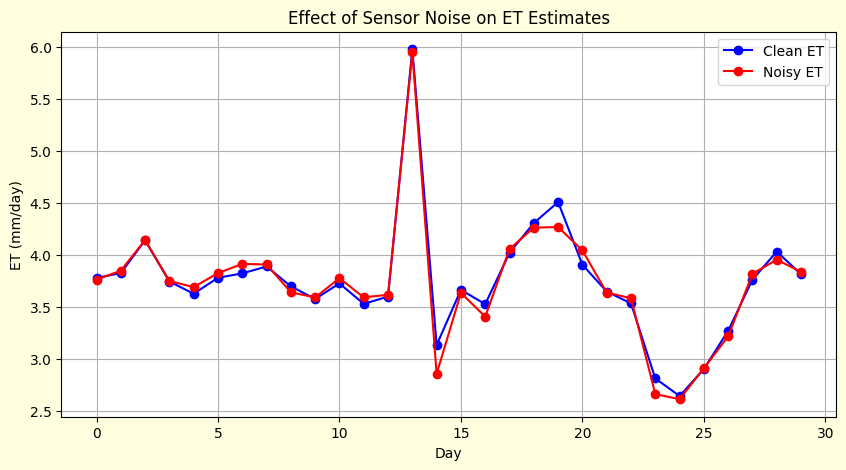

In [26]:
np.random.seed(42)

target_moisture  = 33.0
current_moisture = 28.0

# add noise once to each variable
temp_noisy   = temp_array     + np.random.normal(0, 0.5,  size=len(temp_array))
wind_noisy   = wind_array     + np.random.normal(0, 0.1,  size=len(wind_array))
solar_noisy  = solar_array    + np.random.normal(0, 0.02, size=len(solar_array))
humidity_noisy = humidity_array + np.random.normal(0, 1.0,  size=len(humidity_array))

# clip to valid ranges
temp_noisy   = np.clip(temp_noisy,     0,  50)
wind_noisy   = np.clip(wind_noisy,     0,  20)
solar_noisy  = np.clip(solar_noisy,    0,   1)
humidity_noisy = np.clip(humidity_noisy, 0, 100)

# compute clean and noisy ET
et_clean = et_vectorized_results.copy()
et_noisy = et_vectorized(temp_noisy, wind_noisy, solar_noisy, humidity_noisy)

# compute irrigation recommendations
irrigation_clean = max(0, (target_moisture - current_moisture) + et_clean.mean())
irrigation_noisy = max(0, (target_moisture - current_moisture) + et_noisy.mean())

print("ERROR PROPAGATION RESULTS")
print("="*50)
print("Clean ET mean           :", round(et_clean.mean(), 4), "mm/day")
print("Noisy ET mean           :", round(et_noisy.mean(), 4), "mm/day")
print("Difference in ET        :", round(abs(et_clean.mean() - et_noisy.mean()), 4), "mm/day")
print("="*50)
print("Clean irrigation needed :", round(irrigation_clean, 4), "mm")
print("Noisy irrigation needed :", round(irrigation_noisy, 4), "mm")
print("Difference              :", round(abs(irrigation_clean - irrigation_noisy), 4), "mm")

# plot
plt.figure(figsize=(10, 5), facecolor='lightyellow')
plt.plot(et_clean, color='blue', marker='o', label='Clean ET')
plt.plot(et_noisy, color='red',  marker='o', label='Noisy ET')
plt.title('Effect of Sensor Noise on ET Estimates')
plt.xlabel('Day')
plt.ylabel('ET (mm/day)')
plt.legend()
plt.grid(True)
plt.show()

## Task 6 — Why Numerical Reliability Matters in Scientific Computing

The experiments in this notebook demonstrate two distinct but related
problems that every scientific computing system must address.

### 1. Floating Point Representation Error
Computers cannot represent most decimal numbers exactly in binary.
The result is that simple operations like 0.1 + 0.2 do not produce
exactly 0.3. In isolation this error is negligibly small — around
10^-17. However in a system like HydroSense-Kenya where we chain
hundreds of calculations together across 30 days and three zones,
these errors accumulate. A water balance model that runs for 365 days
could accumulate enough floating point error to shift irrigation
recommendations by a meaningful margin if not handled carefully.
This is why we use np.isclose() and np.allclose() for comparisons
rather than ==, and why we must be careful when summing many small
values together.

### 2. Measurement Noise and Error Propagation
Real sensors are imperfect. Our error propagation experiment showed
that even small random noise of ±0.5°C in temperature, ±0.1 m/s in
wind speed, ±0.02 in solar index, and ±1% in humidity produces a
measurable spread in ET estimates and irrigation recommendations
across 1000 simulations. This means a farmer relying on a single
sensor reading to make an irrigation decision is effectively making
a decision based on an uncertain input. A robust scientific system
must either account for this uncertainty explicitly — as we will do
in the Monte Carlo simulation in Level 5 — or use averaged readings
to reduce the noise effect.

### Conclusion
Numerical reliability is not a theoretical concern — it directly
affects the quality of decisions made from computational models.
In agricultural systems where under-irrigation causes crop stress
and over-irrigation wastes water and energy, unreliable computation
has real economic and environmental consequences. This is why
scientific computing emphasizes not just getting an answer, but
getting a reliable, reproducible, and defensible answer.